# Heart Disease Predictor (Artificial Neural Networks - ANNs)

### 1) Import Libraries 

In [14]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"


#----- Tools, visualizers -----
from utils import skewness_detector, outlier_detector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

#----- Preprocessing, Neural Networks -----
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import tensorflow as tf


### 2) Load Data

In [2]:
# Load dataset
#---------------
data = pd.read_csv(DATA_DIR / "heart-data.csv")
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


### 3) Split Data
Before preprocessing and model training, we need to split the dataset into **train** and **validation** sets.  
- The **training set** is used to learn the patterns.  
- The **validation set** is used to evaluate performance on unseen data, preventing overfitting.  

In [8]:
# Split dataset into train and validation sets
#----------------------------------------------

# Set random state
RANDOM_STATE = 42

# Separate features and labels cols
X = data.drop(columns='HeartDisease') # Features
y = data['HeartDisease'] # Labels

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15 , random_state=RANDOM_STATE, stratify=y
)

print("----Done----")

----Done----


### Preprocessing
Preprocessing ensures that the dataset is clean, consistent, and suitable for Neural Networks.  
In this project, our preprocessing will focus on:  
1. **Handling invalid values**  
   - *RestingBP*: drop rows with 0 (impossible value).  
   - *OldPeak*: replace negative values with 0 (invalid in medical context).  
   - *Cholesterol*: treat 0 as missing values and impute instead of dropping (since there are many).  

2. **Imputation**  
   - For *Cholesterol*, we will impute missing/invalid values.  
   - Options: Mean, Median, or Model-based imputation.  
   - For this project, we will start simple (Median/Mean) then we can test Model-based imputations to compare performance.  

3. **Scaling / Standardization**  
   - Many ML models (e.g., Logistic Regression, SVM, KNN) require features to be on similar scales.  
   - We will apply **StandardScaler** or **MinMaxScaler** depending on the model. 
        - For ANNs we need to scale the values in a specific range (e.g. [0,1]), **MinMaxScaler** is the ideal choice in this case.
 
4. **Encoding categorical features**  
   - Convert categorical variables into numeric form using **One-Hot Encoding** or **Label Encoding** depending on the situation.  

5. *(Optional)* Handling skewness and outliers  
   - For this project, we will skip skewness/outlier handling, since:  
     - Skewness may only affect specific models.  
     - Outliers in medical datasets may represent real patients and should not always be removed.  
 
6. *(Optional)* Convert dataframes into numpy arrays to be fed into the networks.


---


### 4) Core of preprocessing and handling data
> Including 3-5 steps mentioned above.

#### - Pipeline Approach

In [9]:
"""
Three continuous numeric features were spotted having INVALID,
 IMPOSSIBLE vlues BIOLOGICLY & in terms of MEDICAL SCIENCE
 * RestingBP -> 1 case with the value 0 (since it's only one case it's better to be removed)
 * OldPeak -> 13 cases with negative values (there are atleast two ways to consider)
    - Replacing negative values with the baseline which is 0 (clipping)
    - Using median imputation
    -> First option is reasonable since number of cases is low
 * Cholesterol -> 172 cases with the value 0 (almost 20% of values)
 - Zeros can be considered as missing values and be imputed by using median/mean or Model-based techniques
============================================================================================
Continuous numeric features should be scaled and standardized
* Including Features: [Age, RestingBP, Cholesterol, MaxHR, Oldpeak]
* First option for sclaing technique is `MinMaxScaler`
============================================================================================
Categorical features that aren't continuous numeric type should be encoded to
numerical types.
* Including Features: [Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope]
* `FastingBS` was excluded since it's already numeric (binary: 0s 1s), but should be added to the pipeline.
* The encoders could be used are:
- One-Hot Encoding-> For binary categories
- One-Hot Encoding -> For nominal (no order) or Ordinal (ordered) categories
- Ordinal Encoding -> For ordinal (ordered) categories
* In our case for the features, all of encoders can be used for the corresponding categories:
- Sex, ExerciseAngina, FastingBS (Binary) => Label Encoder
- ChestPainType, RestingECG (Nominal) => One-Hot Encoder
- ST_Slope (Ordinal) => Ordinal  or One-Hot Encoding
"""

#-----------------------------------------------------------------------------
# - RestingBP invalid values handling: 
#   Because this part will change the number of rows and values 
#   if the target col SO we need to implement it outside Pipeline 
#   to not run into any problem

# - OldPeak and Cholesterol invalid values handling: 
#   OldPeak gets filtered and negative values will be replaced 
#   with zero, Cholesterol's zero values will be converted into 
#   Nan so that they all will be preprocessed consistently inside pipeline
#-----------------------------------------------------------------------------

# -----RestingBP-----
# Set masks: Keep all rows except the one that's 0
mask_t = X_train['RestingBP'] != 0
mask_v = X_val['RestingBP'] != 0

#  Train
#--------------
# Filter X_train
X_train = X_train[mask_t].reset_index(drop=True)

# Filter y_train
y_train = y_train[mask_t].reset_index(drop=True)

#  Validation
#---------------
# Filter X_val
X_val = X_val[mask_v].reset_index(drop=True)

# Filter y_val
y_val = y_val[mask_v].reset_index(drop=True)


#-----OldPeak-----
# Filter X_train
X_train['Oldpeak'] = X_train['Oldpeak'].apply(lambda x: 0 if x < 0 else x)

# Filter X_val
X_val['Oldpeak'] = X_val['Oldpeak'].apply(lambda x: 0 if x < 0 else x)

# -> Alternative: np.clip()


#-----Choleterol-----

# Convert zeros into Nan
X_train['Cholesterol'] = X_train['Cholesterol'].replace(0, np.nan)
X_val['Cholesterol'] = X_val['Cholesterol'].replace(0, np.nan)

#======================================================================================

f = X_train[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']]

# Check outliers of X_train after low-level cleaning to decide which scaler to use
# Safe zone -> outliers < 5%
df_out = outlier_detector(f)

# Check skewness of X_train after low-level cleaning
df_sk  = skewness_detector(f)

# Combine into one overview DataFrame
df_summary = pd.concat([df_out, df_sk], axis=1).reset_index(drop=True)

#======================================================================================

# Identify columns
#------------------

# Continuous numeric features
con_num_features = ['Age', 'RestingBP', 'MaxHR', 'Cholesterol', 'Oldpeak']

# Categorical features
bin_features = ['Sex', 'ExerciseAngina', 'FastingBS']
nom_features = ['ChestPainType', 'RestingECG']
ord_features = ['ST_Slope']


# Continuos numeric Pipelines
#------------------------------

# Continuous numeric Pipeline 
con_num_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])


# Categorical Pipelines
#------------------------------

# Binary features Pipeline
bin_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder())
])

# Nominal features Pipeline
nom_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe_encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Ordinal features Pipeline
ord_Pipeline = Pipeline(([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder(categories=[['Down', 'Flat', 'Up']]))
]))


# Combine all Pipelines to build preprocessor
preprocessor = ColumnTransformer([
    ("con_num", con_num_Pipeline, con_num_features),
    ("bin", bin_Pipeline, bin_features),
    ("nom", nom_Pipeline, nom_features), 
    ("ord", ord_Pipeline, ord_features)
], remainder="drop")


print("-----Preprocessing with pipeline done-----", end="\n\n")
print("Outlier & Skewness Summary (before scaling):")
df_summary

-----Preprocessing with pipeline done-----

Outlier & Skewness Summary (before scaling):


,Feature,N_outliers,Outlier_pct,Feature,Skewness,Skewness_Exceeding_Threshold
0,RestingBP,23,2.953,RestingBP,0.617980,False
1,Cholesterol,21,2.696,Cholesterol,1.288181,True
2,Oldpeak,12,1.540,Oldpeak,1.100429,True
3,MaxHR,1,0.128,MaxHR,0.163001,False
4,Age,0,0.000,Age,0.218176,False


### 5) Build the architecture and model


#### - Model based on the pipeline approach

In [10]:
#--------------------------------------------------------
# Build the architecture, model and fit, train, evaluate
#--------------------------------------------------------

# 1. Fit the sklearn preprocessor on training features
preprocessor.fit(X_train)                       # X_train: pandas.DataFrame

# 2. Transform -> get NumPy arrays
X_train_proc = preprocessor.transform(X_train)  # usually numpy array
X_val_proc   = preprocessor.transform(X_val)

# 3. Ensure dtypes and shapes are correct for TF
X_train_proc = X_train_proc.astype(np.float32)
X_val_proc   = X_val_proc.astype(np.float32)

# 4. Convert labels to numpy (ints)
y_train_np = np.array(y_train).astype(np.int32).reshape(-1,)
y_val_np   = np.array(y_val).astype(np.int32).reshape(-1,)

# 5. Build Keras model with the right input shape
input_dim = X_train_proc.shape[1]

model = tf.keras.models.Sequential([
    # Input layer
    tf.keras.layers.Input(shape=(input_dim,)),
    # First hidden layer with 16 units
    tf.keras.layers.Dense(16, activation='relu'),
    # Second hidden layer with 8 units 
    tf.keras.layers.Dense(8, activation='relu'),
    # Set dropout to prevent overfitting
    tf.keras.layers.Dropout(0.3),
    # Third hidden layer with 1 unit (output layer)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Stop early if validation loss doesn’t improve for 5 epochs
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ckpt = tf.keras.callbacks.ModelCheckpoint("ann_best.keras", monitor='val_loss', save_best_only=True, verbose=1)

# 6. Fit using numpy arrays
history = model.fit(
    X_train_proc, y_train_np,
    validation_data=(X_val_proc, y_val_np),
    epochs=30,
    callbacks=[early_stop, ckpt]
)

# 7. Evaluate during training
model.evaluate(X_val_proc, y_val_np, verbose=2)


Epoch 1/30
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5361 - loss: 0.6952
Epoch 1: val_loss improved from None to 0.66380, saving model to ann_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5712 - loss: 0.6854 - val_accuracy: 0.6087 - val_loss: 0.6638
Epoch 2/30
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6313 - loss: 0.6641 
Epoch 2: val_loss improved from 0.66380 to 0.63713, saving model to ann_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6624 - loss: 0.6572 - val_accuracy: 0.7391 - val_loss: 0.6371
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6980 - loss: 0.6389 
Epoch 3: val_loss improved from 0.63713 to 0.61203, saving model to ann_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6996 - loss: 0.6319 - val_accuracy: 0.7681 - val_loss: 0.6120
Epoch 4/30
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7437 - loss: 0.5987 
Epoch 4: val_loss improved from 0.61203 to 0.58031, saving model to a

[0.35081806778907776, 0.8768116235733032]

#### **NOTE:**
In preprocessing we use one of the approaches shown (Manual/Pipeline), which the pipeline approach is the common, standard and ideal way of preprocessing. But in this notebook the manual approach was ran.

#### Performance of the model (based on the manual Approach)

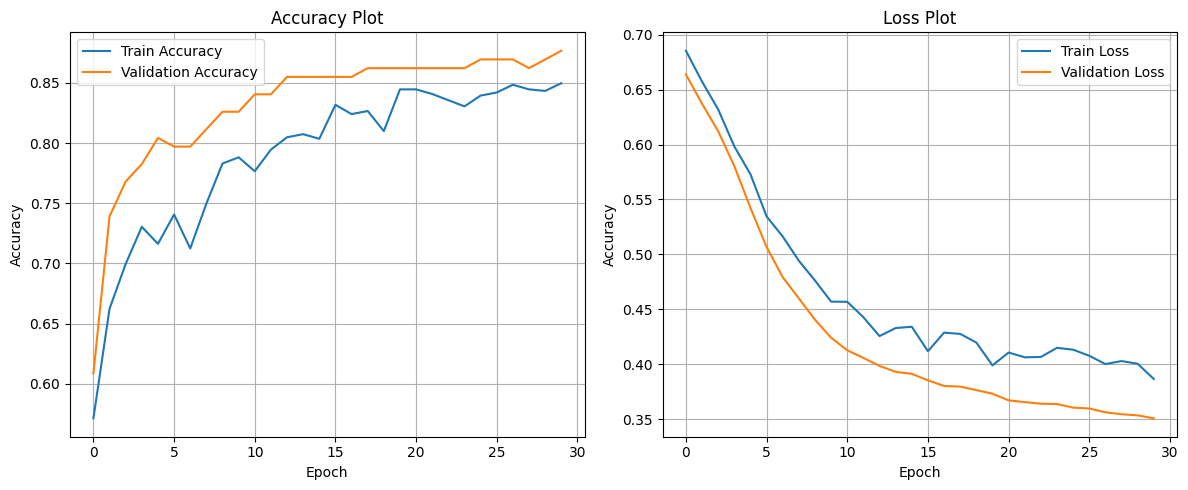

In [11]:
#-------------------------------------
# Visualize performance of the model
#-------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
axes[0].plot(history.history['accuracy'], label="Train Accuracy")
axes[0].plot(history.history['val_accuracy'], label="Validation Accuracy")
axes[0].set_title("Accuracy Plot")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid()
axes[0].legend()

# Loss comparison
axes[1].plot(history.history['loss'], label="Train Loss")
axes[1].plot(history.history['val_loss'], label="Validation Loss")
axes[1].set_title("Loss Plot")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
F1-Score (weighted): 86.934 %
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85        62
           1       0.87      0.89      0.88        76

    accuracy                           0.87       138
   macro avg       0.87      0.87      0.87       138
weighted avg       0.87      0.87      0.87       138



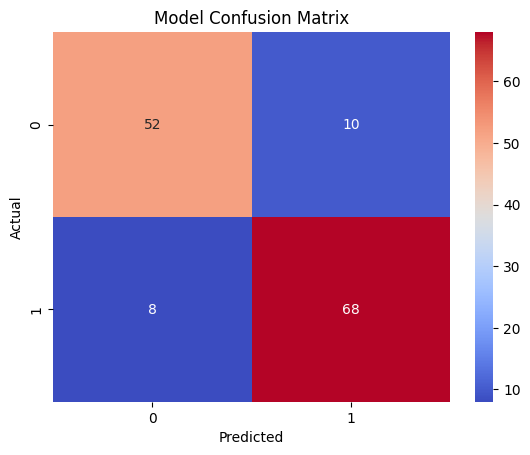

In [13]:
#----------------------------------------------
# More detailed evaluation on validation set
#----------------------------------------------

# Predict
y_pred_probs = model.predict(X_val_proc) # Outputs are probabilities which is between 0 & 1

# For evaluation with below metrics probs need to be converted into binary labels 0 or 1, So:
# Convert probabilities into binary labels
y_pred = (y_pred_probs > 0.45).astype("int32").flatten()

# Evaluate 
# F1-score
print(f"F1-Score (weighted): {round(f1_score(y_val, y_pred, average='weighted') * 100, 3)} %")
# Classification report
print(f"Classification Report:\n{classification_report(y_val, y_pred)}")
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.title("Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [15]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

# Save the preprocessor
joblib.dump(preprocessor, PROJECT_ROOT / "Models/Classification/ANN_preprocessor.joblib")
# Save the model
model.save(PROJECT_ROOT / "Models/Classification/ANN_model.keras")

print("Model Saved: ANN_model.keras",
       "Preprocessor Saved: ANN_preprocessor.joblib",
       sep="    |   ")

Model Saved: ANN_model.keras    |   Preprocessor Saved: ANN_preprocessor.joblib
